Step 1: Generate data points

In [3]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
n = 100  # 100 data points
xi = np.random.uniform(0, 1, n)
epsilon = np.random.uniform(-0.3, 0.3, n)
yi = np.sin(2 * np.pi * xi) + epsilon

Step 2: Function to compute polynomial hypothesis h_θ(x) and Function to compute MSE

In [4]:
def h_theta(x, theta):
    """Compute polynomial: θ_0 + θ_1*x + θ_2*x^2 + ... + θ_D*x^D"""
    result = 0
    for j in range(len(theta)):
        result += theta[j] * (x ** j)
    return result

def compute_mse(xi, yi, theta):
    mse = 0
    for i in range(len(xi)):
        pred = h_theta(xi[i], theta)
        mse += (yi[i] - pred) ** 2
    return mse / len(xi)

Step 3: Stochastic Gradient Descent function

In [5]:
def sgd_train(xi, yi, D, alpha, epochs, verbose=True):
    """Train polynomial regression using SGD"""
    n = len(xi)

    # Initialize parameters theta randomly in [-0.5, 0.5]
    theta = np.random.uniform(-0.5, 0.5, D + 1)

    # Store MSE history
    mse_history = []

    for epoch in range(epochs):
        # Shuffle the data for each epoch
        indices = np.random.permutation(n)

        for i in indices:
            prediction = h_theta(xi[i], theta)
            error = yi[i] - prediction

            # Update each parameter θ_j
            for j in range(D + 1):
                theta[j] = theta[j] + alpha * error * (xi[i] ** j)

        # Compute MSE for this epoch
        mse = compute_mse(xi, yi, theta)
        mse_history.append(mse)

        # Print progress
        if verbose and (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch + 1}/{epochs}, MSE: {mse:.6f}")

    return theta, mse_history

Step 4: Trying different values of D with α = 0.001

In [6]:
print("=" * 60)
print("Testing different polynomial degrees D")
print("=" * 60)

alpha_initial = 0.001
epochs = 1000
D_values = [3, 5, 7, 10, 15, 20]

results_D = {}

for D in D_values:
    print(f"\nTraining with D = {D}, α = {alpha_initial}")
    theta, mse_history = sgd_train(xi, yi, D, alpha_initial, epochs, verbose=False)
    final_mse = mse_history[-1]
    results_D[D] = {
        'theta': theta,
        'mse_history': mse_history,
        'final_mse': final_mse
    }
    print(f"  Final MSE: {final_mse:.6f}")

# Find best D
best_D = min(results_D.keys(), key=lambda d: results_D[d]['final_mse'])
print(f"\n** Best D = {best_D} with MSE = {results_D[best_D]['final_mse']:.6f} **")

Testing different polynomial degrees D

Training with D = 3, α = 0.001
  Final MSE: 0.229845

Training with D = 5, α = 0.001
  Final MSE: 0.189041

Training with D = 7, α = 0.001
  Final MSE: 0.145793

Training with D = 10, α = 0.001
  Final MSE: 0.135177

Training with D = 15, α = 0.001
  Final MSE: 0.129028

Training with D = 20, α = 0.001
  Final MSE: 0.137140

** Best D = 15 with MSE = 0.129028 **


Step 5: Trying different values of α with best D

In [7]:
print("\n" + "=" * 60)
print("Testing different learning rates α")
print("=" * 60)

D_fixed = best_D
alpha_values = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]

results_alpha = {}

for alpha in alpha_values:
    print(f"\nTraining with D = {D_fixed}, α = {alpha}")
    theta, mse_history = sgd_train(xi, yi, D_fixed, alpha, epochs, verbose=False)
    final_mse = mse_history[-1]
    results_alpha[alpha] = {
        'theta': theta,
        'mse_history': mse_history,
        'final_mse': final_mse
    }
    print(f"  Final MSE: {final_mse:.6f}")

# Find best α
best_alpha = min(results_alpha.keys(), key=lambda a: results_alpha[a]['final_mse'])
print(f"\n** Best α = {best_alpha} with MSE = {results_alpha[best_alpha]['final_mse']:.6f} **")


Testing different learning rates α

Training with D = 15, α = 0.0001
  Final MSE: 0.232396

Training with D = 15, α = 0.0005
  Final MSE: 0.143585

Training with D = 15, α = 0.001
  Final MSE: 0.133623

Training with D = 15, α = 0.005
  Final MSE: 0.102451

Training with D = 15, α = 0.01
  Final MSE: 0.080159

Training with D = 15, α = 0.05
  Final MSE: 0.043957

Training with D = 15, α = 0.1
  Final MSE: 0.047996

** Best α = 0.05 with MSE = 0.043957 **


Step 6: Visualization

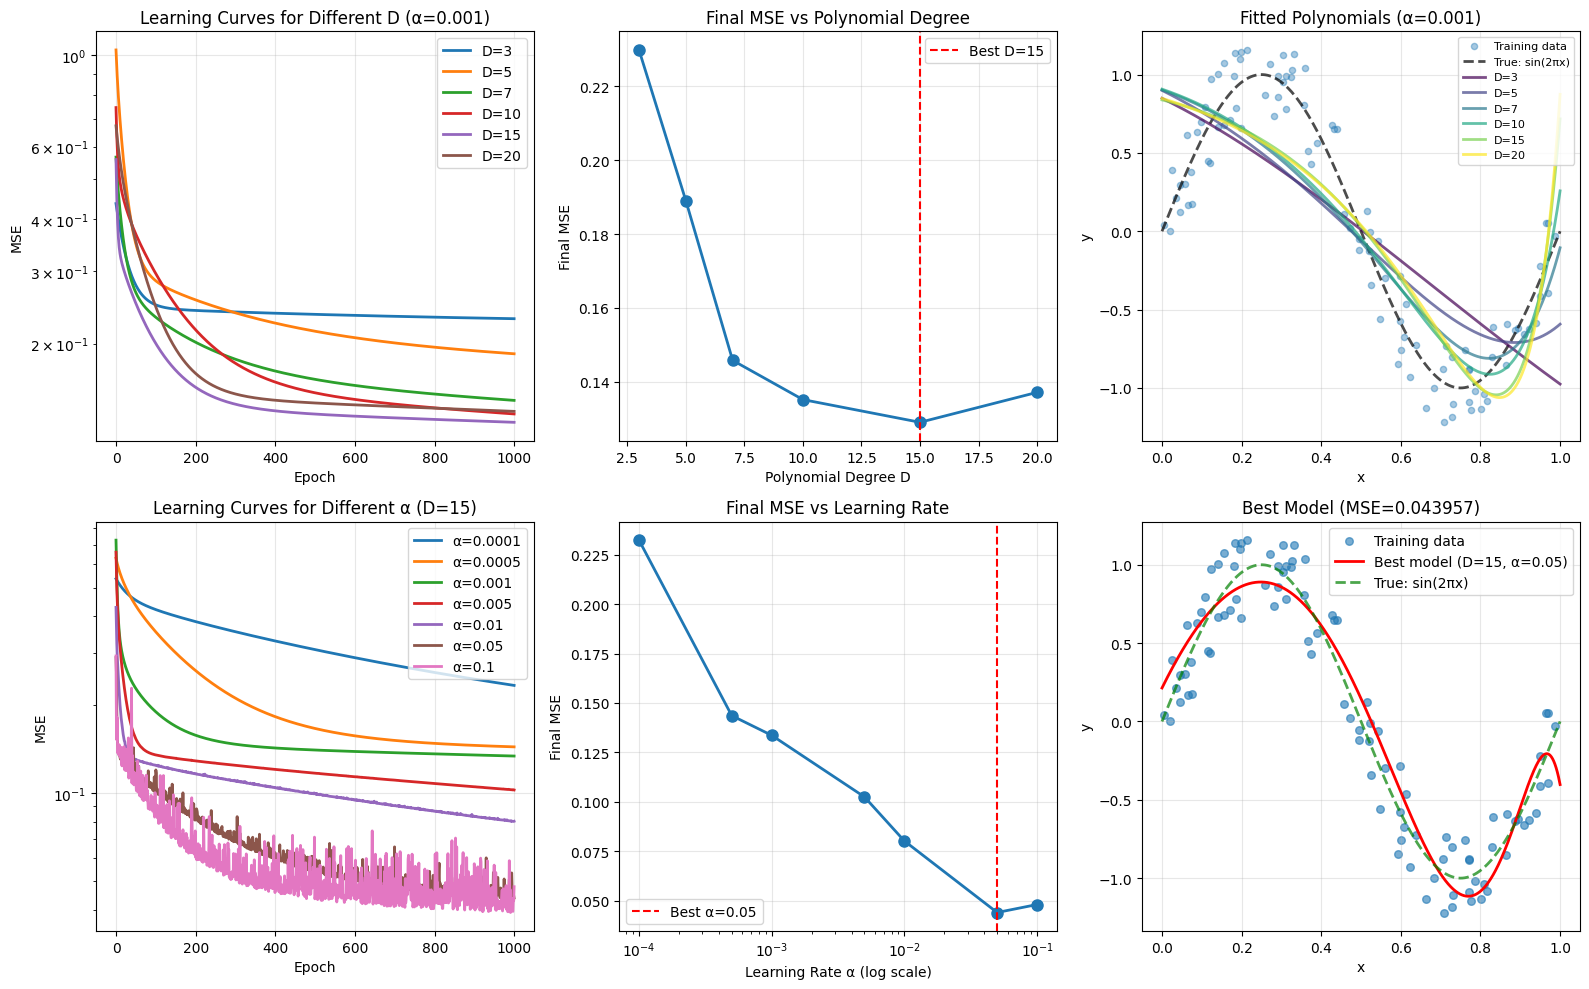

In [10]:
plt.figure(figsize=(16, 10))

# Plot 1: MSE vs Epochs for different D values
plt.subplot(2, 3, 1)
for D in D_values:
    plt.plot(results_D[D]['mse_history'], label=f'D={D}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f'Learning Curves for Different D (α={alpha_initial})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Final MSE vs D
plt.subplot(2, 3, 2)
D_list = list(results_D.keys())
mse_list = [results_D[d]['final_mse'] for d in D_list]
plt.plot(D_list, mse_list, 'o-', linewidth=2, markersize=8)
plt.axvline(x=best_D, color='r', linestyle='--', label=f'Best D={best_D}')
plt.xlabel('Polynomial Degree D')
plt.ylabel('Final MSE')
plt.title('Final MSE vs Polynomial Degree')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Fitted curves for different D
plt.subplot(2, 3, 3)
plt.scatter(xi, yi, alpha=0.4, s=20, label='Training data')
x_plot = np.linspace(0, 1, 1000)
y_true = np.sin(2 * np.pi * x_plot)
plt.plot(x_plot, y_true, 'k--', label='True: sin(2πx)', linewidth=2, alpha=0.7)

colors = plt.cm.viridis(np.linspace(0, 1, len(D_values)))
for idx, D in enumerate(D_values):
    y_plot = np.array([h_theta(x, results_D[D]['theta']) for x in x_plot])
    plt.plot(x_plot, y_plot, color=colors[idx], label=f'D={D}', linewidth=2, alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Fitted Polynomials (α={alpha_initial})')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)

# Plot 4: MSE vs Epochs for different α values
plt.subplot(2, 3, 4)
for alpha in alpha_values:
    plt.plot(results_alpha[alpha]['mse_history'], label=f'α={alpha}', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f'Learning Curves for Different α (D={D_fixed})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 5: Final MSE vs α
plt.subplot(2, 3, 5)
alpha_list = list(results_alpha.keys())
mse_alpha_list = [results_alpha[a]['final_mse'] for a in alpha_list]
plt.semilogx(alpha_list, mse_alpha_list, 'o-', linewidth=2, markersize=8)
plt.axvline(x=best_alpha, color='r', linestyle='--', label=f'Best α={best_alpha}')
plt.xlabel('Learning Rate α (log scale)')
plt.ylabel('Final MSE')
plt.title('Final MSE vs Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Best model fit
plt.subplot(2, 3, 6)
plt.scatter(xi, yi, alpha=0.6, s=30, label='Training data')
y_plot_best = np.array([h_theta(x, results_alpha[best_alpha]['theta']) for x in x_plot])
plt.plot(x_plot, y_plot_best, 'r-', label=f'Best model (D={D_fixed}, α={best_alpha})', linewidth=2)
plt.plot(x_plot, y_true, 'g--', label='True: sin(2πx)', linewidth=2, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Best Model (MSE={results_alpha[best_alpha]["final_mse"]:.6f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step 7: Summary Report

In [11]:
print("\n" + "=" * 60)
print("SUMMARY REPORT")
print("=" * 60)

print("\nResults for different polynomial degrees (α = 0.001):")
print(f"{'D':<5} {'Final MSE':<15}")
print("-" * 20)
for D in D_values:
    marker = " <- BEST" if D == best_D else ""
    print(f"{D:<5} {results_D[D]['final_mse']:<15.6f}{marker}")

print("\nResults for different learning rates (D = {}):".format(D_fixed))
print(f"{'α':<10} {'Final MSE':<15}")
print("-" * 25)
for alpha in alpha_values:
    marker = " <- BEST" if alpha == best_alpha else ""
    print(f"{alpha:<10} {results_alpha[alpha]['final_mse']:<15.6f}{marker}")

print("\n" + "=" * 60)
print("OPTIMAL CONFIGURATION")
print("=" * 60)
print(f"Best polynomial degree: D = {best_D}")
print(f"Best learning rate: α = {best_alpha}")
print(f"Final MSE: {results_alpha[best_alpha]['final_mse']:.6f}")

print("\nLearned parameters θ for best model:")
best_theta = results_alpha[best_alpha]['theta']
for j in range(len(best_theta)):
    print(f"θ_{j} = {best_theta[j]:.6f}")


SUMMARY REPORT

Results for different polynomial degrees (α = 0.001):
D     Final MSE      
--------------------
3     0.229845       
5     0.189041       
7     0.145793       
10    0.135177       
15    0.129028        <- BEST
20    0.137140       

Results for different learning rates (D = 15):
α          Final MSE      
-------------------------
0.0001     0.232396       
0.0005     0.143585       
0.001      0.133623       
0.005      0.102451       
0.01       0.080159       
0.05       0.043957        <- BEST
0.1        0.047996       

OPTIMAL CONFIGURATION
Best polynomial degree: D = 15
Best learning rate: α = 0.05
Final MSE: 0.043957

Learned parameters θ for best model:
θ_0 = 0.213597
θ_1 = 5.164195
θ_2 = -8.596660
θ_3 = -5.058078
θ_4 = -0.407494
θ_5 = 2.027326
θ_6 = 3.079473
θ_7 = 3.907404
θ_8 = 2.728592
θ_9 = 1.923005
θ_10 = 1.018670
θ_11 = 0.292910
θ_12 = -0.953214
θ_13 = -1.479962
θ_14 = -1.651679
θ_15 = -2.610853
